In [ ]:
import os
import pickle
import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import (
    train_test_split,
    GridSearchCV,
    cross_val_score,
    StratifiedKFold
)
from sklearn.preprocessing import (
    StandardScaler,
    LabelEncoder,
    OneHotEncoder,
    FunctionTransformer
)
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    precision_score,
    recall_score,
    f1_score
)
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import (
    RandomForestClassifier,
    ExtraTreesClassifier,
    GradientBoostingClassifier,
    AdaBoostClassifier,
    StackingClassifier
)
from sklearn.svm import SVC
import xgboost as xgb
warnings.filterwarnings('ignore')

In [2]:
if os.path.exists('FertilizerRecommendation.csv'):
    df = pd.read_csv('FertilizerRecommendation.csv')
    
    # Remove duplicates to prevent data leakage (100% accuracy issue)
    initial_shape = df.shape
    df.drop_duplicates(inplace=True)
    print(f'Dataset imported successfully. Dropped {initial_shape[0] - df.shape[0]} duplicate rows.')
else:
    print('Dataset not found')


if os.path.exists('FertilizerRecommendation.csv'):
    df = pd.read_csv('FertilizerRecommendation.csv')
    
    # Remove duplicates to prevent data leakage (100% accuracy issue)
    initial_shape = df.shape
    df.drop_duplicates(inplace=True) 
    
    # Remove rare classes that now have less than 5 samples to prevent train_test_split and KFold from crashing\n",
    class_counts = df['Fertilizer'].value_counts()
    valid_classes = class_counts[class_counts >= 5].index
    df = df[df['Fertilizer'].isin(valid_classes)]
    print(f'Dataset imported successfully. Dropped {initial_shape[0] - df.shape[0]} duplicate/rare rows.')

else:
    print('Dataset not found')

Dataset imported successfully. Dropped 414 duplicate rows.
Dataset imported successfully. Dropped 433 duplicate/rare rows.


#### Exploratory Data Analysis

In [3]:
df.head()

,Temparature,Humidity,Moisture,Soil_Type,Crop_Type,Nitrogen,Potassium,Phosphorous,Fertilizer
0,20,83,26,Clayey,rice,90,49,36,Urea
1,25,84,32,Loamy,rice,66,59,36,Urea
2,33,64,50,Loamy,Wheat,41,0,0,Urea
3,34,65,54,Loamy,Wheat,38,0,0,Urea
4,38,72,51,Loamy,Wheat,39,0,0,Urea


In [4]:
df.shape

(119, 9)

This dataset consists of **552 rows** in total.

Each row has **9** columns representing **Temperature, Humidity, Moisture, Soil_Type, Crop_Type, Nitrogen, Phosphorous, Potassium, Fertilizer (target)**

Nitrogen, Phosphorous and Potassium values represent the NPK values in the soil. Temperature, humidity and moisture are the average values of the sorroundings environment respectively.

The Label column tells us the type of crop that's best suited to grow based on these conditions. Label is the value we will be predicting

In [5]:
cols = df.columns

print('Columns: \n')

for col in cols:
    print(col)

Columns: 

Temparature
Humidity
Moisture
Soil_Type
Crop_Type
Nitrogen
Potassium
Phosphorous
Fertilizer


In [6]:
fertilizers = df['Fertilizer'].unique()

print('Fertilizers: \n')

for fertilizer in fertilizers:
    print(fertilizer)

Fertilizers: 

Urea
TSP
DAP
28-28
20-20
17-17-17
14-35-14
10-26-26


In [7]:
df.dtypes

Temparature    int64
Humidity       int64
Moisture       int64
Soil_Type        str
Crop_Type        str
Nitrogen       int64
Potassium      int64
Phosphorous    int64
Fertilizer       str
dtype: object

In [8]:
# Class Distribution

df['Fertilizer'].value_counts()

Fertilizer
Urea        27
DAP         26
28-28       17
20-20       14
14-35-14    14
TSP          7
17-17-17     7
10-26-26     7
Name: count, dtype: int64

In [9]:
# FEATURE ENGINEERING

df['NPK_sum'] = (
    df['Nitrogen'] +
    df['Potassium'] +
    df['Phosphorous']
)

df['NP_ratio'] = (
    df['Nitrogen'] /
    (df['Phosphorous'] + 1)
)

df['PK_ratio'] = (
    df['Phosphorous'] /
    (df['Potassium'] + 1)
)

df['temp_humidity'] = (
    df['Temparature'] *
    df['Humidity']
)

In [10]:

# FEATURES & TARGET
X = df.drop(columns=['Fertilizer'])
y = df['Fertilizer']

# LABEL ENCODING TARGET
le = LabelEncoder()
y_encoded = le.fit_transform(y)

# CATEGORICAL & NUMERICAL COLUMNS
categorical_cols = [
    'Soil_Type',
    'Crop_Type'
]

numerical_cols = [
    col for col in X.columns
    if col not in categorical_cols
]

# PREPROCESSING
numeric_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer([

    ('num',
     numeric_transformer,
     numerical_cols),

    ('cat',
     categorical_transformer,
     categorical_cols)
])

In [11]:
models = {
    "Logistic Regression": LogisticRegression(
        max_iter=3000,
        class_weight='balanced',
        random_state=42
    ),

    "Naive Bayes": GaussianNB(),

    "KNN": KNeighborsClassifier(
        n_neighbors=5
    ),

    "Decision Tree": DecisionTreeClassifier(
        max_depth=15,
        class_weight='balanced',
        random_state=42
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=300,
        max_depth=15,
        class_weight='balanced',
        random_state=42,
        n_jobs=-1
    ),

    "Gradient Boosting": GradientBoostingClassifier(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=5,
        random_state=42
    ),

    "SVM": SVC(
        kernel='rbf',
        probability=True,
        class_weight='balanced',
        random_state=42
    ),

    "XGBoost": xgb.XGBClassifier(
        n_estimators=500,
        learning_rate=0.03,
        max_depth=5,
        subsample=0.9,
        colsample_bytree=0.9,
        objective='multi:softprob',
        eval_metric='mlogloss',
        random_state=42,
        n_jobs=-1
    )
}

In [12]:
# TRAIN TEST SPLIT
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.2,
    stratify=y_encoded,
    random_state=42
)

# CROSS VALIDATION
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# STORE RESULTS
results = []


In [13]:
# TRAIN & EVALUATE MODELS

for model_name, model in models.items():
    print(f"\nTraining {model_name}...")

    # Special handling for Naive Bayes
    if model_name == "Naive Bayes":
        pipeline = Pipeline([
            ('preprocessor', preprocessor),
            ('to_dense', FunctionTransformer(
                lambda x: x if isinstance(x, np.ndarray)
                else x.toarray(),
                accept_sparse=True
            )),
            ('classifier', model)
        ])

    else:
        pipeline = Pipeline([
            ('preprocessor', preprocessor),
            ('classifier', model)
        ])

    # Train
    pipeline.fit(X_train, y_train)

    # Predict
    y_pred = pipeline.predict(X_test)

    # Metrics
    accuracy = accuracy_score(
        y_test,
        y_pred
    )

    macro_f1 = f1_score(
        y_test,
        y_pred,
        average='macro'
    )

    weighted_f1 = f1_score(
        y_test,
        y_pred,
        average='weighted'
    )

    # Cross Validation
    cv_scores = cross_val_score(
        pipeline,
        X,
        y_encoded,
        cv=cv,
        scoring='f1_macro',
        n_jobs=-1
    )

    cv_mean = cv_scores.mean()
    cv_std = cv_scores.std()

    results.append([
        model_name,
        accuracy,
        macro_f1,
        weighted_f1,
        cv_mean,
        cv_std
    ])

    print(f"Accuracy: {accuracy:.4f}")
    print(f"Macro F1: {macro_f1:.4f}")
    print(f"CV Macro F1: {cv_mean:.4f}")


Training Logistic Regression...


Accuracy: 0.8750
Macro F1: 0.8780
CV Macro F1: 0.7043

Training Naive Bayes...
Accuracy: 0.7917
Macro F1: 0.8515
CV Macro F1: 0.5278

Training KNN...
Accuracy: 0.5417
Macro F1: 0.3650
CV Macro F1: 0.4321

Training Decision Tree...
Accuracy: 0.7917
Macro F1: 0.7154
CV Macro F1: 0.8026

Training Random Forest...
Accuracy: 0.9167
Macro F1: 0.9175
CV Macro F1: 0.8535

Training Gradient Boosting...
Accuracy: 0.8750
Macro F1: 0.7716
CV Macro F1: 0.7591

Training SVM...
Accuracy: 0.7917
Macro F1: 0.7970
CV Macro F1: 0.7139

Training XGBoost...
Accuracy: 0.8750
Macro F1: 0.7634
CV Macro F1: 0.7677


In [14]:
# RESULTS DATAFRAME

results_df = pd.DataFrame(
    results,
    columns=[
        'Model',
        'Accuracy',
        'Macro F1',
        'Weighted F1',
        'CV Macro F1 Mean',
        'CV Std'
    ]
)

# Sort
results_df = results_df.sort_values(
    by='CV Macro F1 Mean',
    ascending=False
)

print("\nFINAL MODEL COMPARISON:\n")
print(results_df)


FINAL MODEL COMPARISON:

                 Model  Accuracy  Macro F1  Weighted F1  CV Macro F1 Mean  \
4        Random Forest  0.916667  0.917468     0.914797          0.853485   
3        Decision Tree  0.791667  0.715422     0.789773          0.802635   
7              XGBoost  0.875000  0.763393     0.867560          0.767720   
5    Gradient Boosting  0.875000  0.771635     0.866186          0.759058   
6                  SVM  0.791667  0.796970     0.791162          0.713870   
0  Logistic Regression  0.875000  0.877976     0.885913          0.704260   
1          Naive Bayes  0.791667  0.851515     0.789141          0.527840   
2                  KNN  0.541667  0.365025     0.538847          0.432124   

     CV Std  
4  0.035487  
3  0.042966  
7  0.054211  
5  0.087255  
6  0.065503  
0  0.077836  
1  0.141047  
2  0.065312  


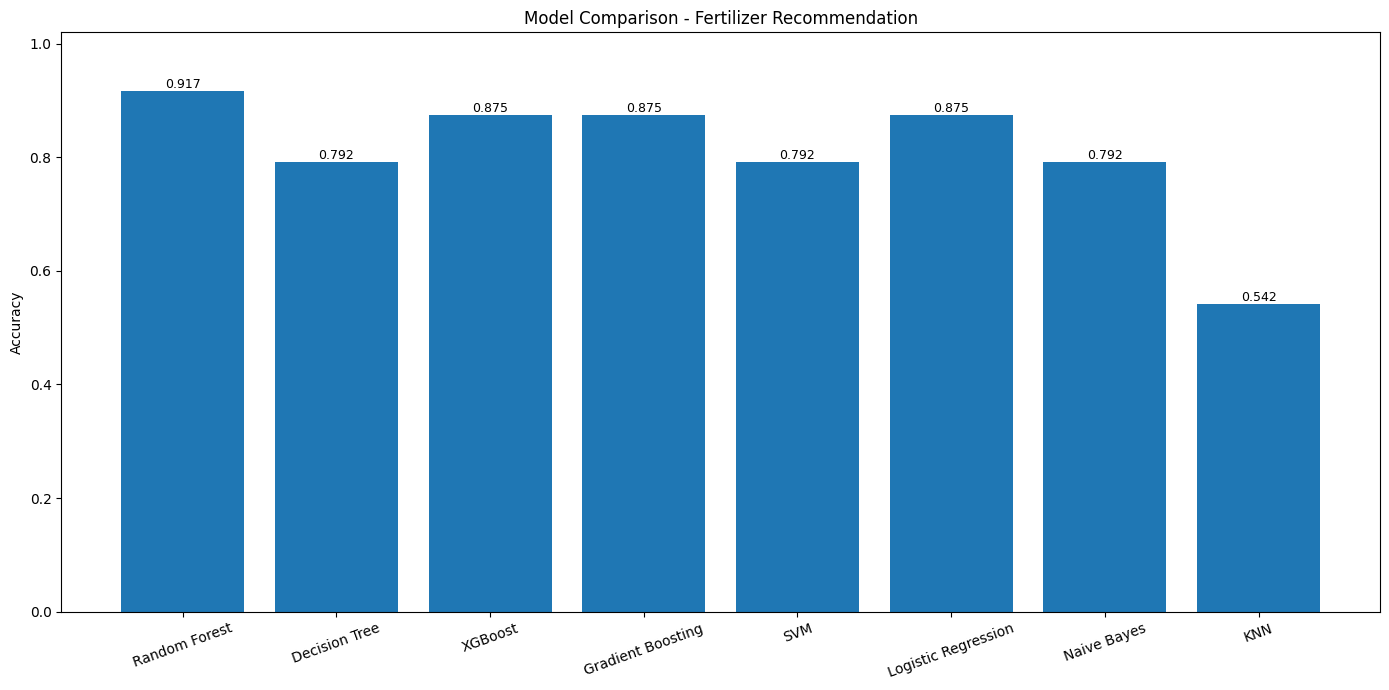

In [15]:
# VISUALIZATION

plt.figure(figsize=(14, 7))

bars = plt.bar(
    results_df['Model'],
    results_df['Accuracy']
)

plt.xticks(rotation=20)
plt.ylabel("Accuracy")
plt.title("Model Comparison - Fertilizer Recommendation")
plt.ylim(0, 1.02)

# Add values
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 0.005,
        f"{height:.3f}",
        ha='center',
        fontsize=9
    )

plt.tight_layout()
plt.show()

In [16]:
# BEST MODEL

best_model = results_df.iloc[0]
print("\nBest Model:\n")
print(best_model)


Best Model:

Model               Random Forest
Accuracy                 0.916667
Macro F1                 0.917468
Weighted F1              0.914797
CV Macro F1 Mean         0.853485
CV Std                   0.035487
Name: 4, dtype: object


In [17]:
# Save the Model

final_rf_model = models["Random Forest"]
final_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', final_rf_model)
])

final_pipeline.fit(X, y_encoded)

export_data = {
    'model': final_pipeline,
    'label_encoder': le
}

export_path = 'Fertilizer_Recommendation_Model.pkl'

with open(export_path, 'wb') as file:
    pickle.dump(export_data, file)

print(f"Model and Label Encoder successfully exported to: {export_path}")


Model and Label Encoder successfully exported to: Fertilizer_Recommendation_Model.pkl
